# Advanced Feature Engineering for Employee Churn Prediction

This notebook implements comprehensive feature engineering to improve model performance:
- Interaction features
- Polynomial features
- Binning/categorization
- Ratio features
- Satisfaction composites

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load and Prepare Data

In [2]:
# Load data
df = pd.read_csv('../data/employee-attrition.csv')

# Convert column names to lowercase
df.columns = df.columns.str.lower()

# Convert attrition to binary
df['attrition'] = (df['attrition'] == 'Yes').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nAttrition distribution:\n{df['attrition'].value_counts()}")
print(f"\nAttrition rate: {df['attrition'].mean():.2%}")

Dataset shape: (1470, 35)

Attrition distribution:
attrition
0    1233
1     237
Name: count, dtype: int64

Attrition rate: 16.12%


## 2. Feature Engineering Functions

In [3]:
def create_interaction_features(df):
    """
    Create interaction features that capture relationships between variables.
    """
    df_new = df.copy()
    
    # Age × Experience alignment
    df_new['age_experience_ratio'] = df_new['age'] / (df_new['totalworkingyears'] + 1)
    
    # Income × Job Level alignment
    df_new['income_per_joblevel'] = df_new['monthlyincome'] / (df_new['joblevel'] + 1)
    
    # OverTime × WorkLifeBalance conflict
    df_new['overtime_wlb_conflict'] = ((df_new['overtime'] == 'Yes').astype(int) * 
                                        (5 - df_new['worklifebalance']))
    
    # Distance × BusinessTravel burden
    travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
    df_new['commute_burden'] = (df_new['distancefromhome'] * 
                                 df_new['businesstravel'].map(travel_map))
    
    # Job satisfaction × Environment satisfaction
    df_new['overall_job_satisfaction'] = (df_new['jobsatisfaction'] * 
                                           df_new['environmentsatisfaction'])
    
    # Years at company × Job level (career progression)
    df_new['career_progression_rate'] = df_new['joblevel'] / (df_new['yearsatcompany'] + 1)
    
    return df_new

def create_polynomial_features(df, features, degree=2):
    """
    Create polynomial features for key numeric variables.
    """
    df_new = df.copy()
    
    for feature in features:
        if feature in df.columns:
            df_new[f'{feature}_squared'] = df_new[feature] ** 2
            if degree >= 3:
                df_new[f'{feature}_cubed'] = df_new[feature] ** 3
    
    return df_new

def create_binned_features(df):
    """
    Create categorical bins for continuous variables.
    """
    df_new = df.copy()
    
    # Age groups
    df_new['age_group'] = pd.cut(df_new['age'], 
                                   bins=[0, 30, 45, 100], 
                                   labels=['Young', 'Mid-Career', 'Senior'])
    
    # Income quartiles
    df_new['income_quartile'] = pd.qcut(df_new['monthlyincome'], 
                                          q=4, 
                                          labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    # Tenure groups
    df_new['tenure_group'] = pd.cut(df_new['yearsatcompany'], 
                                      bins=[-1, 2, 5, 10, 100], 
                                      labels=['New', 'Mid', 'Experienced', 'Veteran'])
    
    # Distance categories
    df_new['distance_category'] = pd.cut(df_new['distancefromhome'], 
                                           bins=[-1, 5, 15, 100], 
                                           labels=['Near', 'Medium', 'Far'])
    
    return df_new

def create_ratio_features(df):
    """
    Create ratio features that normalize by relevant denominators.
    """
    df_new = df.copy()
    
    # Income per year of experience
    df_new['income_per_exp_year'] = df_new['monthlyincome'] / (df_new['totalworkingyears'] + 1)
    
    # Promotions per year at company
    df_new['promotion_frequency'] = 1 / (df_new['yearssincelastpromotion'] + 1)
    
    # Training hours per year
    df_new['training_intensity'] = df_new['trainingtimeslastyear'] / (df_new['yearsatcompany'] + 1)
    
    # Time in current role vs total tenure
    df_new['role_stability'] = df_new['yearsincurrentrole'] / (df_new['yearsatcompany'] + 1)
    
    # Manager tenure vs employee tenure
    df_new['manager_stability'] = df_new['yearswithcurrmanager'] / (df_new['yearsatcompany'] + 1)
    
    # Percent salary hike per job level
    df_new['hike_per_level'] = df_new['percentsalaryhike'] / (df_new['joblevel'] + 1)
    
    return df_new

def create_satisfaction_features(df):
    """
    Create composite satisfaction features.
    """
    df_new = df.copy()
    
    satisfaction_cols = ['environmentsatisfaction', 'jobsatisfaction', 
                         'relationshipsatisfaction', 'worklifebalance']
    
    # Average satisfaction
    df_new['avg_satisfaction'] = df_new[satisfaction_cols].mean(axis=1)
    
    # Satisfaction variance (consistency)
    df_new['satisfaction_variance'] = df_new[satisfaction_cols].var(axis=1)
    
    # Minimum satisfaction (weakest link)
    df_new['min_satisfaction'] = df_new[satisfaction_cols].min(axis=1)
    
    # Count of low satisfaction scores (<= 2)
    df_new['low_satisfaction_count'] = (df_new[satisfaction_cols] <= 2).sum(axis=1)
    
    return df_new

def create_tenure_features(df):
    """
    Create advanced tenure-related features.
    """
    df_new = df.copy()
    
    # Time since last promotion relative to tenure
    df_new['promotion_gap_ratio'] = df_new['yearssincelastpromotion'] / (df_new['yearsatcompany'] + 1)
    
    # Role stagnation (years in role - years since promotion)
    df_new['role_stagnation'] = df_new['yearsincurrentrole'] - df_new['yearssincelastpromotion']
    
    # Early career indicator
    df_new['early_career'] = ((df_new['totalworkingyears'] <= 5) & 
                               (df_new['yearsatcompany'] <= 2)).astype(int)
    
    # Job hopper indicator (many companies, low tenure)
    df_new['job_hopper'] = ((df_new['numcompaniesworked'] >= 4) & 
                             (df_new['yearsatcompany'] <= 3)).astype(int)
    
    return df_new

## 3. Apply Feature Engineering

In [4]:
# Create all engineered features
print("Creating interaction features...")
df_engineered = create_interaction_features(df)

print("Creating polynomial features...")
poly_features = ['age', 'totalworkingyears', 'monthlyincome', 'yearsatcompany']
df_engineered = create_polynomial_features(df_engineered, poly_features, degree=2)

print("Creating binned features...")
df_engineered = create_binned_features(df_engineered)

print("Creating ratio features...")
df_engineered = create_ratio_features(df_engineered)

print("Creating satisfaction features...")
df_engineered = create_satisfaction_features(df_engineered)

print("Creating tenure features...")
df_engineered = create_tenure_features(df_engineered)

print(f"\nOriginal features: {df.shape[1]}")
print(f"Engineered features: {df_engineered.shape[1]}")
print(f"New features added: {df_engineered.shape[1] - df.shape[1]}")

Creating interaction features...
Creating polynomial features...
Creating binned features...
Creating ratio features...
Creating satisfaction features...
Creating tenure features...

Original features: 35
Engineered features: 63
New features added: 28


## 4. Feature Analysis

In [5]:
# Get new feature names
original_cols = set(df.columns)
new_cols = [col for col in df_engineered.columns if col not in original_cols]

print(f"\nNew features created ({len(new_cols)}):")
for col in sorted(new_cols):
    print(f"  - {col}")


New features created (28):
  - age_experience_ratio
  - age_group
  - age_squared
  - avg_satisfaction
  - career_progression_rate
  - commute_burden
  - distance_category
  - early_career
  - hike_per_level
  - income_per_exp_year
  - income_per_joblevel
  - income_quartile
  - job_hopper
  - low_satisfaction_count
  - manager_stability
  - min_satisfaction
  - monthlyincome_squared
  - overall_job_satisfaction
  - overtime_wlb_conflict
  - promotion_frequency
  - promotion_gap_ratio
  - role_stability
  - role_stagnation
  - satisfaction_variance
  - tenure_group
  - totalworkingyears_squared
  - training_intensity
  - yearsatcompany_squared



Top 15 new features by correlation with attrition:
overtime_wlb_conflict       0.241543
early_career                0.239873
age_experience_ratio        0.206554
income_per_joblevel         0.169761
avg_satisfaction            0.159092
role_stability              0.157625
manager_stability           0.153259
hike_per_level              0.148903
role_stagnation             0.145203
min_satisfaction            0.138044
age_squared                 0.137086
training_intensity          0.132908
monthlyincome_squared       0.131434
low_satisfaction_count      0.128604
overall_job_satisfaction    0.126752
Name: attrition, dtype: float64


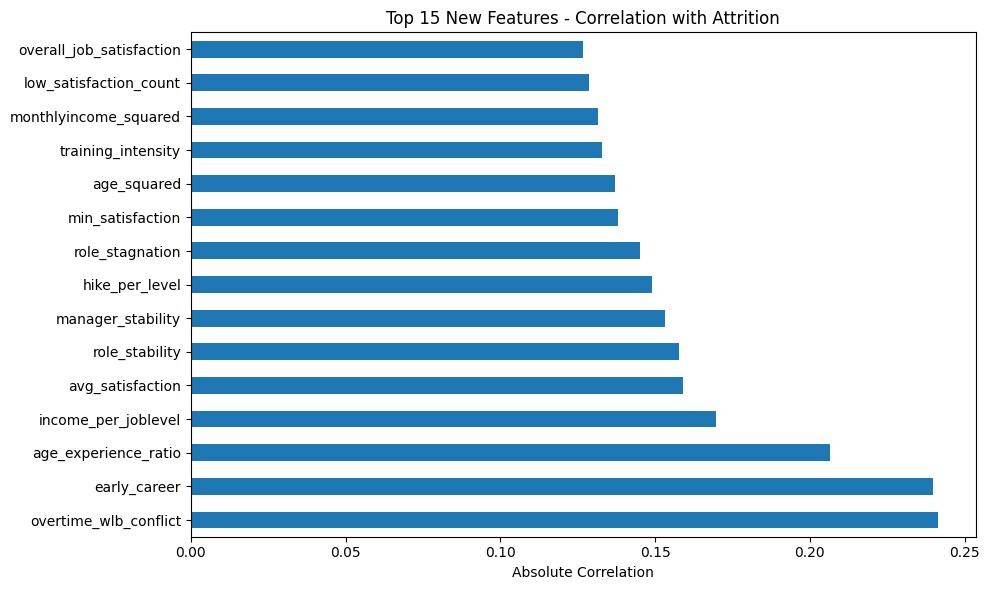

In [6]:
# Analyze correlation of new numeric features with attrition
numeric_new_features = df_engineered[new_cols].select_dtypes(include=[np.number]).columns

if len(numeric_new_features) > 0:
    correlations = df_engineered[list(numeric_new_features) + ['attrition']].corr()['attrition'].drop('attrition')
    correlations_sorted = correlations.abs().sort_values(ascending=False)
    
    print("\nTop 15 new features by correlation with attrition:")
    print(correlations_sorted.head(15))
    
    # Visualize top correlations
    plt.figure(figsize=(10, 6))
    correlations_sorted.head(15).plot(kind='barh')
    plt.title('Top 15 New Features - Correlation with Attrition')
    plt.xlabel('Absolute Correlation')
    plt.tight_layout()
    plt.show()

## 5. Check for Multicollinearity

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select numeric features for VIF calculation
numeric_features = df_engineered.select_dtypes(include=[np.number]).columns
numeric_features = [col for col in numeric_features if col != 'attrition']

# Calculate VIF for a sample of features (to avoid computational issues)
sample_features = numeric_features[:30]  # First 30 numeric features
X_vif = df_engineered[sample_features].fillna(0)

vif_data = pd.DataFrame()
vif_data["Feature"] = sample_features
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(sample_features))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVariance Inflation Factor (VIF) - Top 10:")
print(vif_data.head(10))
print("\nFeatures with VIF > 10 (potential multicollinearity):")
print(vif_data[vif_data['VIF'] > 10])


Variance Inflation Factor (VIF) - Top 10:
                 Feature        VIF
11         monthlyincome  55.088354
9               joblevel  21.219942
27   income_per_joblevel  15.014104
19     totalworkingyears   6.464474
22        yearsatcompany   4.660383
25  yearswithcurrmanager   2.872456
23    yearsincurrentrole   2.831367
2       distancefromhome   2.741216
29        commute_burden   2.738700
26  age_experience_ratio   2.543255

Features with VIF > 10 (potential multicollinearity):
                Feature        VIF
11        monthlyincome  55.088354
9              joblevel  21.219942
27  income_per_joblevel  15.014104


## 6. Prepare Train/Test Split

In [8]:
# Remove constant columns
constant_cols = ['employeecount', 'standardhours', 'over18']
df_engineered = df_engineered.drop(columns=[col for col in constant_cols if col in df_engineered.columns])

# Separate features and target
X = df_engineered.drop('attrition', axis=1)
y = df_engineered['attrition']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain attrition rate: {y_train.mean():.2%}")
print(f"Test attrition rate: {y_test.mean():.2%}")


Train set: (984, 59)
Test set: (486, 59)

Train attrition rate: 16.16%
Test attrition rate: 16.05%


## 7. Save Engineered Data

In [9]:
# Save engineered dataset
df_engineered.to_csv('../data/employee-attrition-engineered.csv', index=False)
print("\nEngineered dataset saved to: ../data/employee-attrition-engineered.csv")

# Save feature names for reference
feature_info = pd.DataFrame({
    'feature': X.columns,
    'is_new': [col in new_cols for col in X.columns],
    'dtype': X.dtypes.values
})
feature_info.to_csv('../data/feature_info.csv', index=False)
print("Feature information saved to: ../data/feature_info.csv")


Engineered dataset saved to: ../data/employee-attrition-engineered.csv
Feature information saved to: ../data/feature_info.csv


## 8. Summary Statistics

In [10]:
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)
print(f"\nOriginal features: {len(original_cols)}")
print(f"Total features after engineering: {X.shape[1]}")
print(f"New features created: {len(new_cols)}")
print(f"\nFeature categories:")
print(f"  - Interaction features: {len([c for c in new_cols if 'ratio' in c or 'burden' in c or 'conflict' in c or 'progression' in c])}")
print(f"  - Polynomial features: {len([c for c in new_cols if 'squared' in c or 'cubed' in c])}")
print(f"  - Binned features: {len([c for c in new_cols if 'group' in c or 'quartile' in c or 'category' in c])}")
print(f"  - Ratio features: {len([c for c in new_cols if 'per' in c or 'frequency' in c or 'intensity' in c or 'stability' in c])}")
print(f"  - Satisfaction features: {len([c for c in new_cols if 'satisfaction' in c])}")
print(f"  - Tenure features: {len([c for c in new_cols if 'stagnation' in c or 'career' in c or 'hopper' in c])}")
print("\n" + "="*60)


FEATURE ENGINEERING SUMMARY

Original features: 35
Total features after engineering: 59
New features created: 28

Feature categories:
  - Interaction features: 5
  - Polynomial features: 4
  - Binned features: 4
  - Ratio features: 9
  - Satisfaction features: 5
  - Tenure features: 4

